# Fall Detection — OpenPose Skeleton + LSTM/GRU

Basé sur : *"A Framework for Fall Detection Based on OpenPose Skeleton and LSTM/GRU Models"* (Lin, Dong, Kuan, Huang — Appl. Sci. 2021).

**Adaptations documentées par rapport au papier** (dataset FallDeWideo, format COCO-18, 3 classes) :
- Format squelette : COCO-18 (pas de point MidHip distinct) → 14 points retenus au lieu de 15 (28 valeurs au lieu de 30).
- 3 classes (fall/nfall1/nfall2) au lieu de 2 (fall/non-fall) dans le papier.
- Split 80/20 train/test **fidèle au papier**, + validation carvée depuis le train (le papier ne précise pas de val séparée).
- CrossEntropy **sans label smoothing** (fidèle à l'Éq. 20 du papier).
- Stride de fenêtrage réduit (recouvrement accru) pour augmenter le nombre de séquences — équivalent à la "data enhancement" que le papier applique lui-même sur ses données brutes.
- Gradient clipping ajouté (léger filet de sécurité, non présent dans le papier) et un jitter gaussien sur l'entrée train (anti-overfitting, dataset restant petit malgré l'augmentation du stride).


In [1]:
# ============================================================
# CELLULE 1 — CONFIGURATION
# ============================================================
import os, gc, re, pickle, random, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import psutil
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def mem_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}  —  RAM: {mem_gb():.2f} Go")
if DEVICE.type != "cuda":
    print("⚠️ Aucun GPU détecté — active un accélérateur GPU puis relance (pas indispensable ici : réseaux petits).")

OUT_DIR = "/kaggle/working/fall_lstm_gru"
CACHE_DIR = "/kaggle/working/cache_seq"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

CLASSES = {"fall": 0, "nfall1": 1, "nfall2": 2}
IDX2CLASS = {v: k for k, v in CLASSES.items()}
N_CLASSES = 3

H, W = 36, 64                # résolution native des heatmaps OpenPose (inchangée)
CONF_THRESH = 0.1            # seuil de confiance sous lequel un point est "manquant"

# --- Fenêtrage (papier : groupes de 100 frames) ---
WINDOW_LEN = 100
STRIDE = 20                  # réduit vs 50 précédemment : plus de recouvrement -> plus de séquences
                              # (équivalent à la "data enhancement" du papier sur ses données brutes)
MISSING_TOLERANCE = 0.67     # papier Eq.8 : au-delà de 67% manquant, pas de compensation

# --- Split (papier : 80% train / 20% test, pas de val séparée précisée) ---
TEST_FRACTION = 0.20
VAL_FRACTION_OF_TRAIN = 0.15  # carvé depuis le 80% train (amélioration méthodo vs papier, documentée)

# --- Hyperparamètres modèle (papier Tables 5-6, meilleurs résultats sur RP-Normalization) ---
LSTM_HIDDEN = 512
GRU_HIDDEN  = 512
LR_LSTM = 0.01
LR_GRU  = 0.01
EPOCHS_SEQ = 500              # papier Table 3 (RNN/LSTM/GRU entraînés sur 500 epochs)
WEIGHT_DECAY = 1e-4
DROPOUT_SEQ = 0.3              # déviation mineure vs papier (aucun dropout) — dataset encore petit
INPUT_NOISE_STD = 0.02         # jitter gaussien train uniquement — déviation mineure, anti-overfitting
GRAD_CLIP_NORM = 5.0           # filet de sécurité non présent dans le papier

print("✅ Configuration chargée")


Device: cuda  —  RAM: 0.74 Go
✅ Configuration chargée


In [2]:
# ============================================================
# CELLULE 2 — DÉCOUVERTE DU DATASET
# ============================================================
def find_dataset_root():
    candidates = [
        Path("/kaggle/input/falldewideoo"),
        Path("/kaggle/input/datasets/imanemokhtari/falldewideoo"),
    ]
    candidates += [p for p in Path("/kaggle/input").glob("*") if p.is_dir()]
    for root in candidates:
        if not root.exists():
            continue
        op_files = list(root.rglob("full_0.pk"))
        if any("/openpose/" in f.as_posix() for f in op_files):
            return root
    raise FileNotFoundError("Dataset FallDeWideo introuvable — vérifie qu'il est attaché (Add Input).")

DATA_ROOT = find_dataset_root()
print("DATA_ROOT:", DATA_ROOT)

def file_number(path):
    m = re.search(r"full_(\d+)\.pk$", str(path))
    return int(m.group(1)) if m else 999

all_pk = list(DATA_ROOT.rglob("full_*.pk"))
normal_openpose  = [p for p in all_pk if p.as_posix().endswith("/openpose/openpose/" + p.name)]
missing_openpose = [p for p in all_pk if p.as_posix().endswith("/missing/missing/openpose/" + p.name)]
openpose_by_number = {file_number(p): p for p in normal_openpose}
openpose_by_number.update({file_number(p): p for p in missing_openpose})
OPENPOSE_FILES = [openpose_by_number[n] for n in sorted(openpose_by_number)]
N_FILES = len(OPENPOSE_FILES)
print("Fichiers OpenPose trouvés :", N_FILES)
assert N_FILES >= 1, "Aucun fichier OpenPose trouvé."
for i, p in enumerate(OPENPOSE_FILES):
    print(f"  full_{i}.pk → {p}")
print("✅ Dataset localisé")


DATA_ROOT: /kaggle/input/datasets/imanemokhtari/falldewideoo
Fichiers OpenPose trouvés : 10
  full_0.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/missing/missing/openpose/full_0.pk
  full_1.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_1.pk
  full_2.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_2.pk
  full_3.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_3.pk
  full_4.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_4.pk
  full_5.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_5.pk
  full_6.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_6.pk
  full_7.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_7.pk
  full_8.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/openpose/full_8.pk
  full_9.pk → /kaggle/input/datasets/imanemokhtari/falldewideoo/openpose/

In [3]:
# ============================================================
# CELLULE 3 — INDEXATION GLOBALE (label par frame, RAM-safe)
# ============================================================
INDEX_CACHE = os.path.join(CACHE_DIR, "global_index.pkl")

def guess_label(pic_path):
    s = str(pic_path).lower()
    if "nfall1" in s: return "nfall1"
    if "nfall2" in s: return "nfall2"
    if "fall" in s:   return "fall"
    return None

if os.path.exists(INDEX_CACHE):
    print("Index déjà en cache — chargement...")
    index_df = pd.read_pickle(INDEX_CACHE)
else:
    records = []
    for file_idx, path in enumerate(OPENPOSE_FILES):
        t0 = time.time()
        df = pd.read_pickle(path)
        labels = df["pic"].apply(guess_label)
        n_unmatched = labels.isna().sum()
        if n_unmatched > 0:
            print(f"  ⚠️ full_{file_idx}.pk : {n_unmatched} lignes sans label reconnu (ignorées)")
        for row_idx, lab in enumerate(labels):
            if lab is not None:
                records.append((file_idx, row_idx, lab))
        dt = time.time() - t0
        print(f"full_{file_idx}.pk : {len(df)} lignes lues en {dt:.1f}s — RAM: {mem_gb():.2f} Go")
        del df, labels
        gc.collect()

    index_df = pd.DataFrame(records, columns=["file_idx", "row_idx", "label"])
    index_df["label_id"] = index_df["label"].map(CLASSES)
    index_df.to_pickle(INDEX_CACHE)
    print(f"\nIndex sauvegardé → {INDEX_CACHE}")

print("\n" + "="*50)
print(f"Total frames indexées : {len(index_df)}")
print(index_df["label"].value_counts())
print("="*50)
print("✅ Index global construit")


full_0.pk : 4020 lignes lues en 5.9s — RAM: 1.86 Go
full_1.pk : 4020 lignes lues en 4.0s — RAM: 1.86 Go
full_2.pk : 4020 lignes lues en 4.0s — RAM: 1.86 Go
full_3.pk : 4020 lignes lues en 3.9s — RAM: 1.86 Go
full_4.pk : 4020 lignes lues en 3.8s — RAM: 1.86 Go
full_5.pk : 4020 lignes lues en 4.2s — RAM: 1.87 Go
full_6.pk : 4020 lignes lues en 4.1s — RAM: 1.87 Go
full_7.pk : 4020 lignes lues en 4.1s — RAM: 1.87 Go
full_8.pk : 4020 lignes lues en 4.1s — RAM: 1.87 Go
full_9.pk : 4020 lignes lues en 4.3s — RAM: 1.87 Go

Index sauvegardé → /kaggle/working/cache_seq/global_index.pkl

Total frames indexées : 40200
label
nfall1    15000
nfall2    14300
fall      10900
Name: count, dtype: int64
✅ Index global construit


Points sélectionnés (correspondance papier, sans MidHip — non disponible en COCO-18) :
['Nose', 'Neck', 'RSho', 'RElb', 'RWri', 'LSho', 'LElb', 'LWri', 'RHip', 'RKnee', 'RAnkle', 'LHip', 'LKnee', 'LAnkle'] — 14 points (papier: 15 points, dont MidHip)
full_0.pk : 4020 frames décodées en 2.5s — % points manquants (conf<0.1): 22.5%
full_1.pk : 4020 frames décodées en 1.8s — % points manquants (conf<0.1): 22.3%
full_2.pk : 4020 frames décodées en 1.8s — % points manquants (conf<0.1): 18.8%
full_3.pk : 4020 frames décodées en 2.0s — % points manquants (conf<0.1): 19.9%
full_4.pk : 4020 frames décodées en 1.8s — % points manquants (conf<0.1): 16.0%
full_5.pk : 4020 frames décodées en 2.0s — % points manquants (conf<0.1): 18.2%
full_6.pk : 4020 frames décodées en 1.8s — % points manquants (conf<0.1): 19.0%
full_7.pk : 4020 frames décodées en 1.8s — % points manquants (conf<0.1): 22.6%
full_8.pk : 4020 frames décodées en 1.8s — % points manquants (conf<0.1): 18.6%
full_9.pk : 4020 frames décod

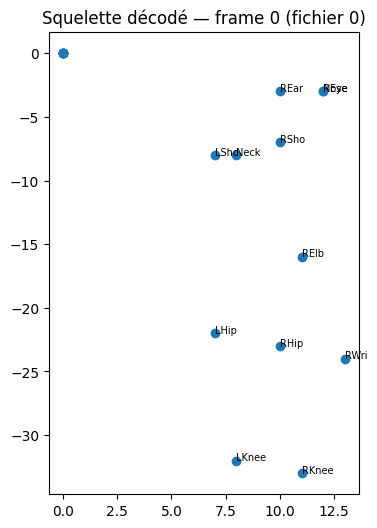

✅ Décodage des points-clés terminé


In [4]:
# ============================================================
# CELLULE 4 — DÉCODAGE DIRECT DES POINTS-CLÉS 2D (depuis 'aff', sans passer par un .npy 57 canaux)
# ============================================================
# Optimisation vs le notebook MobileNet : on ne lit QUE la colonne 'aff' (19 canaux,
# 18 parties du corps COCO + 1 fond) directement depuis chaque .pk — pas besoin de
# 'kpt' (PAF, 38 canaux) ni de construire le gros tenseur 57 canaux, qui ne sert
# qu'aux CNN. Économie disque et temps significative pour ce notebook LSTM/GRU seul.

COCO18_NAMES = ["Nose","Neck","RSho","RElb","RWri","LSho","LElb","LWri",
                "RHip","RKnee","RAnkle","LHip","LKnee","LAnkle","REye","LEye","REar","LEar"]
N_JOINTS_RAW = 18
SELECTED_JOINTS = list(range(14))   # sous-ensemble COCO-18 correspondant au papier (sans MidHip, absent en COCO-18)
JOINT_NAMES_SEL = [COCO18_NAMES[i] for i in SELECTED_JOINTS]
print("Points sélectionnés (correspondance papier, sans MidHip — non disponible en COCO-18) :")
print(JOINT_NAMES_SEL, f"— {len(JOINT_NAMES_SEL)} points (papier: 15 points, dont MidHip)")

KP_DIR = os.path.join(CACHE_DIR, "keypoints")
os.makedirs(KP_DIR, exist_ok=True)
kp_manifest_path = os.path.join(KP_DIR, "kp_manifest.pkl")

if os.path.exists(kp_manifest_path):
    with open(kp_manifest_path, "rb") as f:
        kp_manifest = pickle.load(f)
    print("Points-clés déjà extraits — chargement du manifest.")
else:
    kp_manifest = []
    for file_idx, path in enumerate(OPENPOSE_FILES):
        t0 = time.time()
        df = pd.read_pickle(path)
        aff = np.stack(df["aff"].values).astype(np.float32)   # (N, 19, 36, 64) — lecture directe, pas de fichier intermédiaire lourd
        aff = aff[:, :N_JOINTS_RAW, :, :]                       # (N, 18, 36, 64) — on exclut le canal de fond
        N = aff.shape[0]

        flat = aff.reshape(N, N_JOINTS_RAW, -1)
        conf = flat.max(axis=-1)
        flat_idx = flat.argmax(axis=-1)
        yy = flat_idx // W
        xx = flat_idx % W
        xy = np.stack([xx, yy], axis=-1).astype(np.float32)     # (N, 18, 2)

        missing_mask = conf < CONF_THRESH
        xy[missing_mask] = 0.0

        xy_path = os.path.join(KP_DIR, f"kp_xy_{file_idx}.npy")
        conf_path = os.path.join(KP_DIR, f"kp_conf_{file_idx}.npy")
        np.save(xy_path, xy)
        np.save(conf_path, conf)
        kp_manifest.append({"file_idx": file_idx, "xy_path": xy_path, "conf_path": conf_path, "n_samples": N})

        pct_missing = missing_mask.mean() * 100
        dt = time.time() - t0
        print(f"full_{file_idx}.pk : {N} frames décodées en {dt:.1f}s — % points manquants (conf<{CONF_THRESH}): {pct_missing:.1f}%")
        del df, aff, flat, conf, flat_idx, xy, missing_mask
        gc.collect()

    with open(kp_manifest_path, "wb") as f:
        pickle.dump(kp_manifest, f)

# Vérification visuelle rapide (1 frame) — squelette anatomiquement cohérent attendu
test_xy = np.load(kp_manifest[0]["xy_path"])
test_conf = np.load(kp_manifest[0]["conf_path"])
frame_i = 0
plt.figure(figsize=(4,6))
xs, ys = test_xy[frame_i,:,0], test_xy[frame_i,:,1]
plt.scatter(xs, -ys)
for i, name in enumerate(COCO18_NAMES):
    if test_conf[frame_i, i] >= CONF_THRESH:
        plt.annotate(name, (xs[i], -ys[i]), fontsize=7)
plt.title(f"Squelette décodé — frame {frame_i} (fichier 0)")
plt.savefig(os.path.join(OUT_DIR, "skeleton_check.png"), dpi=100)
plt.show()
del test_xy, test_conf
gc.collect()
print("✅ Décodage des points-clés terminé")


In [5]:
# ============================================================
# CELLULE 5 — RP-NORMALIZATION (Relative Position Normalization, Éq. 2-7 du papier)
# ============================================================
IDX_RHIP, IDX_LHIP = 8, 11   # indices dans SELECTED_JOINTS
x_c, y_c = W / 2.0, H / 2.0

FEAT_DIR = os.path.join(CACHE_DIR, "features_rp")
os.makedirs(FEAT_DIR, exist_ok=True)
feat_manifest_path = os.path.join(FEAT_DIR, "feat_manifest.pkl")

if os.path.exists(feat_manifest_path):
    with open(feat_manifest_path, "rb") as f:
        feat_manifest = pickle.load(f)
    print("Features RP-normalisées déjà calculées — chargement du manifest.")
else:
    feat_manifest = []
    for km in kp_manifest:
        file_idx = km["file_idx"]
        xy_full = np.load(km["xy_path"])
        conf_full = np.load(km["conf_path"])
        xy = xy_full[:, SELECTED_JOINTS, :].copy()
        conf = conf_full[:, SELECTED_JOINTS]
        missing_mask = conf < CONF_THRESH

        # Référence centrale : moyenne RHip/LHip (substitut du MidHip, absent en COCO-18)
        hip_x = (xy[:, IDX_RHIP, 0] + xy[:, IDX_LHIP, 0]) / 2.0
        hip_y = (xy[:, IDX_RHIP, 1] + xy[:, IDX_LHIP, 1]) / 2.0
        both_hips_missing = missing_mask[:, IDX_RHIP] & missing_mask[:, IDX_LHIP]
        x_dis = np.where(both_hips_missing, 0.0, hip_x - x_c)
        y_dis = np.where(both_hips_missing, 0.0, hip_y - y_c)

        rx = xy[:, :, 0] - x_dis[:, None]
        ry = xy[:, :, 1] - y_dis[:, None]
        rx[missing_mask] = 0.0
        ry[missing_mask] = 0.0

        feat = np.stack([rx, ry], axis=-1).reshape(rx.shape[0], -1).astype(np.float32)

        feat_path = os.path.join(FEAT_DIR, f"feat_{file_idx}.npy")
        mask_path = os.path.join(FEAT_DIR, f"mask_{file_idx}.npy")
        np.save(feat_path, feat)
        np.save(mask_path, missing_mask)
        feat_manifest.append({"file_idx": file_idx, "feat_path": feat_path, "mask_path": mask_path,
                               "n_samples": feat.shape[0]})
        print(f"full_{file_idx}: features RP-normalisées ({feat.shape[1]}-dim) sauvegardées — {feat.shape}")
        del xy_full, conf_full, xy, conf, missing_mask, rx, ry, feat
        gc.collect()

    with open(feat_manifest_path, "wb") as f:
        pickle.dump(feat_manifest, f)

print(f"\nDimension du vecteur de features par frame : {2*len(SELECTED_JOINTS)} "
      f"(papier: 30 = 15 points x 2 ; ici: {2*len(SELECTED_JOINTS)} = {len(SELECTED_JOINTS)} points x 2)")
print("✅ RP-normalization terminée")


full_0: features RP-normalisées (28-dim) sauvegardées — (4020, 28)
full_1: features RP-normalisées (28-dim) sauvegardées — (4020, 28)
full_2: features RP-normalisées (28-dim) sauvegardées — (4020, 28)
full_3: features RP-normalisées (28-dim) sauvegardées — (4020, 28)
full_4: features RP-normalisées (28-dim) sauvegardées — (4020, 28)
full_5: features RP-normalisées (28-dim) sauvegardées — (4020, 28)
full_6: features RP-normalisées (28-dim) sauvegardées — (4020, 28)
full_7: features RP-normalisées (28-dim) sauvegardées — (4020, 28)
full_8: features RP-normalisées (28-dim) sauvegardées — (4020, 28)
full_9: features RP-normalisées (28-dim) sauvegardées — (4020, 28)

Dimension du vecteur de features par frame : 28 (papier: 30 = 15 points x 2 ; ici: 28 = 14 points x 2)
✅ RP-normalization terminée


In [6]:
# ============================================================
# CELLULE 6 — FENÊTRAGE (séquences) + INTERPOLATION LINÉAIRE (papier Éq. 8, seuil 67%)
# ============================================================
# Stride réduit (20 au lieu de 50) : plus de recouvrement entre fenêtres consécutives
# -> nettement plus de séquences générées. C'est l'équivalent, pour notre dataset,
# de la "data enhancement" que le papier applique lui-même à ses données brutes pour
# passer de quelques dizaines d'enregistrements à des centaines de "groupes" d'entraînement.
# Contrepartie assumée et documentée : les fenêtres se chevauchent donc davantage,
# ce qui augmente la corrélation entre séquences voisines (moins d'information
# réellement "nouvelle" par séquence supplémentaire) — compensé par le split
# stratifié + le jitter/dropout appliqués à l'entraînement (cellule 8).

def interpolate_window(feat_win, mask_win):
    feat_win = feat_win.copy()
    for j in range(len(SELECTED_JOINTS)):
        miss_frac = mask_win[:, j].mean()
        if miss_frac == 0:
            continue
        if miss_frac > MISSING_TOLERANCE:
            continue
        for coord in (0, 1):
            col = j*2 + coord
            s = pd.Series(feat_win[:, col])
            s[mask_win[:, j]] = np.nan
            s = s.interpolate(method="linear", limit_direction="both")
            feat_win[:, col] = s.values
    return feat_win

SEQ_CACHE = os.path.join(CACHE_DIR, f"sequences_stride{STRIDE}.pkl")
if os.path.exists(SEQ_CACHE):
    with open(SEQ_CACHE, "rb") as f:
        seq_data = pickle.load(f)
    X_seq, y_seq = seq_data["X"], seq_data["y"]
    print("Séquences déjà construites — chargement du cache.")
else:
    windows_X, windows_y = [], []
    for fm in feat_manifest:
        file_idx = fm["file_idx"]
        feat = np.load(fm["feat_path"])
        mask = np.load(fm["mask_path"])
        row_idx_this_file = index_df[index_df["file_idx"] == file_idx].sort_values("row_idx")
        y_frame = row_idx_this_file["label_id"].values

        start = 0
        n = len(y_frame)
        while start < n:
            end = start + 1
            while end < n and y_frame[end] == y_frame[start]:
                end += 1
            lab = y_frame[start]
            pos = start
            while pos + WINDOW_LEN <= end:
                fw = feat[pos:pos+WINDOW_LEN]
                mw = mask[pos:pos+WINDOW_LEN]
                fw_interp = interpolate_window(fw, mw)
                windows_X.append(fw_interp)
                windows_y.append(lab)
                pos += STRIDE
            start = end

    X_seq = np.stack(windows_X).astype(np.float32)
    y_seq = np.array(windows_y, dtype=np.int64)
    with open(SEQ_CACHE, "wb") as f:
        pickle.dump({"X": X_seq, "y": y_seq}, f)

print(f"\nNombre total de séquences construites : {len(y_seq)}  (stride={STRIDE}, fenêtre={WINDOW_LEN})")
print(f"Shape : {X_seq.shape}")
dist = pd.Series(y_seq).map(IDX2CLASS).value_counts()
print("Distribution des classes (séquences) :")
print(dist)
print((dist/dist.sum()*100).round(1).astype(str) + " %")



Nombre total de séquences construites : 1659  (stride=20, fenêtre=100)
Shape : (1659, 100, 28)
Distribution des classes (séquences) :
nfall1    636
nfall2    582
fall      441
Name: count, dtype: int64
nfall1    38.3 %
nfall2    35.1 %
fall      26.6 %
Name: count, dtype: object


In [7]:
# ============================================================
# CELLULE 7 — SPLIT 80/20 TRAIN/TEST (fidèle au papier) + VALIDATION carvée depuis le train
# ============================================================
# Le papier ne précise pas de split de validation séparé ("916 training / 224 test").
# Pour un monitoring propre sans fuite de données, on carve une validation DEPUIS
# le train (jamais depuis le test), en gardant le test set à exactement 20% comme le papier.

idx_all = np.arange(len(y_seq))
train_full_idx, test_idx_seq = train_test_split(
    idx_all, test_size=TEST_FRACTION, stratify=y_seq, random_state=SEED
)
train_idx_seq, val_idx_seq = train_test_split(
    train_full_idx, test_size=VAL_FRACTION_OF_TRAIN,
    stratify=y_seq[train_full_idx], random_state=SEED
)

# Mise à l'échelle des coordonnées (résolution heatmap -> approx [-1,1])
X_seq_scaled = X_seq.copy()
X_seq_scaled[:, :, 0::2] /= (W / 2.0)
X_seq_scaled[:, :, 1::2] /= (H / 2.0)

X_train_seq = torch.from_numpy(X_seq_scaled[train_idx_seq]).float().to(DEVICE)
y_train_seq = torch.from_numpy(y_seq[train_idx_seq]).long().to(DEVICE)
X_val_seq   = torch.from_numpy(X_seq_scaled[val_idx_seq]).float().to(DEVICE)
y_val_seq   = torch.from_numpy(y_seq[val_idx_seq]).long().to(DEVICE)
X_test_seq  = torch.from_numpy(X_seq_scaled[test_idx_seq]).float().to(DEVICE)
y_test_seq  = torch.from_numpy(y_seq[test_idx_seq]).long().to(DEVICE)

print(f"Total séquences : {len(y_seq)}")
print(f"Train: {X_train_seq.shape[0]}  Val: {X_val_seq.shape[0]}  Test: {X_test_seq.shape[0]}  "
      f"(Test = {X_test_seq.shape[0]/len(y_seq)*100:.1f}% — fidèle au 20% du papier)")
for name, y_split in [("Train", y_train_seq), ("Val", y_val_seq), ("Test", y_test_seq)]:
    dist = pd.Series(y_split.cpu().numpy()).map(IDX2CLASS).value_counts()
    print(f"{name}: {dist.to_dict()}")

counts_seq = pd.Series(y_train_seq.cpu().numpy()).value_counts().sort_index().values
class_weights_seq = torch.tensor(
    (counts_seq.sum() / (len(counts_seq) * counts_seq)), dtype=torch.float32
).to(DEVICE)
print(f"\nPoids de classe (train) : {dict(zip(IDX2CLASS.values(), class_weights_seq.cpu().numpy()))}")

INPUT_SIZE_SEQ = X_seq.shape[-1]
print(f"\nDimension d'entrée séquence : {INPUT_SIZE_SEQ}  |  Longueur séquence : {WINDOW_LEN}")
print("✅ Données séquentielles prêtes")


Total séquences : 1659
Train: 1127  Val: 200  Test: 332  (Test = 20.0% — fidèle au 20% du papier)
Train: {'nfall1': 432, 'nfall2': 395, 'fall': 300}
Val: {'nfall1': 77, 'nfall2': 70, 'fall': 53}
Test: {'nfall1': 127, 'nfall2': 117, 'fall': 88}

Poids de classe (train) : {'fall': np.float32(1.2522222), 'nfall1': np.float32(0.86959875), 'nfall2': np.float32(0.9510549)}

Dimension d'entrée séquence : 28  |  Longueur séquence : 100
✅ Données séquentielles prêtes


In [8]:
# ============================================================
# CELLULE 8 — MODÈLE (LSTM/GRU, conforme au papier) + fonctions d'entraînement/évaluation
# ============================================================
class SequenceFallNet(nn.Module):
    def __init__(self, cell_type, input_size=INPUT_SIZE_SEQ, hidden_size=512,
                 num_classes=N_CLASSES, num_layers=1, dropout=DROPOUT_SEQ):
        super().__init__()
        self.cell_type = cell_type
        if cell_type == "lstm":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        elif cell_type == "gru":
            self.rnn = nn.GRU(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        else:
            raise ValueError(cell_type)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)   # Softmax géré par CrossEntropyLoss

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        last = self.dropout(last)
        return self.fc(last)

def compute_metrics(logits, y_true):
    preds = logits.argmax(dim=1)
    acc = (preds == y_true).float().mean().item()
    f1 = f1_score(y_true.cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
    return acc, f1

def train_full_seq(model, name, epochs=EPOCHS_SEQ, lr=1e-2, class_weights=class_weights_seq):
    ckpt_best = os.path.join(OUT_DIR, f"best_{name}.pt")
    criterion = nn.CrossEntropyLoss(weight=class_weights)   # sans label smoothing — fidèle au papier (Éq. 20)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

    hist = {"train_loss":[], "train_acc":[], "train_f1":[],
            "val_loss":[], "val_acc":[], "val_f1":[], "lr":[]}
    best_val_f1 = -1.0
    print(f"\n{'='*60}\nEntraînement : {name} — {epochs} epochs (full-batch, {len(y_train_seq)} séquences)\n{'='*60}")
    t0 = time.time()
    for epoch in range(1, epochs+1):
        model.train()
        optimizer.zero_grad()
        noise = torch.randn_like(X_train_seq) * INPUT_NOISE_STD
        out = model(X_train_seq + noise)   # jitter différent à chaque epoch — anti-overfitting
        loss = criterion(out, y_train_seq)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()
        tr_acc, tr_f1 = compute_metrics(out.detach(), y_train_seq)

        model.eval()
        with torch.no_grad():
            out_val = model(X_val_seq)
            val_loss = criterion(out_val, y_val_seq).item()
        val_acc, val_f1 = compute_metrics(out_val, y_val_seq)

        hist["train_loss"].append(loss.item()); hist["train_acc"].append(tr_acc); hist["train_f1"].append(tr_f1)
        hist["val_loss"].append(val_loss); hist["val_acc"].append(val_acc); hist["val_f1"].append(val_f1)
        hist["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_f1 > best_val_f1
        if is_best:
            best_val_f1 = val_f1
            torch.save({"epoch": epoch, "model_state": model.state_dict(),
                        "val_f1": float(val_f1), "val_acc": float(val_acc)}, ckpt_best)

        if epoch % 25 == 0 or epoch == 1 or epoch == epochs or is_best:
            flag = " ⭐ best" if is_best else ""
            print(f"[{name}] Epoch {epoch:3d}/{epochs} | train_f1={tr_f1:.4f} | "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}{flag}")

    total_time = time.time() - t0
    print(f"\n✅ {name} terminé — {epochs} epochs en {total_time:.1f}s — meilleur val_f1: {best_val_f1:.4f}")
    with open(os.path.join(OUT_DIR, f"history_{name}.pkl"), "wb") as f:
        pickle.dump(hist, f)
    return hist, ckpt_best, best_val_f1

def load_ckpt(path):
    return torch.load(path, map_location=DEVICE, weights_only=False)  # nos propres checkpoints, sans risque

def evaluate_on_test_seq(model, ckpt_path, name=""):
    ckpt = load_ckpt(ckpt_path)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    with torch.no_grad():
        out = model(X_test_seq)
    preds = out.argmax(dim=1).cpu().numpy()
    labels = y_test_seq.cpu().numpy()
    acc = (preds == labels).mean()
    f1_macro = f1_score(labels, preds, average="macro")
    report = classification_report(labels, preds, target_names=list(CLASSES.keys()), digits=4)

    print(f"\n{'='*50}\n{name} — Évaluation TEST SET (checkpoint epoch {ckpt['epoch']})\n{'='*50}")
    print(f"Test accuracy : {acc:.4f}   Test F1-macro : {f1_macro:.4f}\n")
    print(report)

    fig, ax = plt.subplots(figsize=(6,5))
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=list(CLASSES.keys()),
        ax=ax, cmap="Blues", normalize="true", values_format=".2f"
    )
    ax.set_title(f"{name} — Matrice de confusion (test, normalisée)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"confmat_{name}.png"), dpi=120)
    plt.show()

    return {"test_acc": acc, "test_f1_macro": f1_macro, "report": report, "y_true": labels, "y_pred": preds}

def plot_history(history, title_prefix=""):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0,0].plot(epochs_range, history["train_loss"], label="Train")
    axes[0,0].plot(epochs_range, history["val_loss"], label="Val")
    axes[0,0].set_title(f"{title_prefix}Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
    axes[0,1].plot(epochs_range, history["train_acc"], label="Train")
    axes[0,1].plot(epochs_range, history["val_acc"], label="Val")
    axes[0,1].set_title(f"{title_prefix}Accuracy"); axes[0,1].set_xlabel("Epoch"); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
    axes[1,0].plot(epochs_range, history["train_f1"], label="Train")
    axes[1,0].plot(epochs_range, history["val_f1"], label="Val")
    axes[1,0].set_title(f"{title_prefix}F1-macro"); axes[1,0].set_xlabel("Epoch"); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)
    axes[1,1].plot(epochs_range, history["lr"], color="green")
    axes[1,1].set_title(f"{title_prefix}Learning Rate"); axes[1,1].set_xlabel("Epoch"); axes[1,1].grid(alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(OUT_DIR, f"{title_prefix.strip().replace(' ','_').replace('—','') or 'curves'}.png")
    plt.savefig(fname, dpi=120)
    plt.show()
    print(f"Figure sauvegardée → {fname}")

all_results = {}
print("✅ Architecture et fonctions d'entraînement/évaluation prêtes")


✅ Architecture et fonctions d'entraînement/évaluation prêtes


# LSTM

LSTM — paramètres : 1,111,555

Entraînement : LSTM — 500 epochs (full-batch, 1127 séquences)
[LSTM] Epoch   1/500 | train_f1=0.1852 | val_loss=1.9588 val_acc=0.3550 val_f1=0.1820 ⭐ best
[LSTM] Epoch   2/500 | train_f1=0.1780 | val_loss=3.7116 val_acc=0.3850 val_f1=0.1853 ⭐ best
[LSTM] Epoch   5/500 | train_f1=0.1402 | val_loss=1.3333 val_acc=0.3550 val_f1=0.2056 ⭐ best
[LSTM] Epoch   9/500 | train_f1=0.2197 | val_loss=1.0940 val_acc=0.3250 val_f1=0.2392 ⭐ best
[LSTM] Epoch  14/500 | train_f1=0.3026 | val_loss=1.0948 val_acc=0.4600 val_f1=0.3723 ⭐ best
[LSTM] Epoch  18/500 | train_f1=0.3698 | val_loss=1.0593 val_acc=0.4350 val_f1=0.4377 ⭐ best
[LSTM] Epoch  24/500 | train_f1=0.4075 | val_loss=1.0072 val_acc=0.4500 val_f1=0.4525 ⭐ best
[LSTM] Epoch  25/500 | train_f1=0.4513 | val_loss=0.9951 val_acc=0.4700 val_f1=0.4513
[LSTM] Epoch  33/500 | train_f1=0.4148 | val_loss=0.9568 val_acc=0.5450 val_f1=0.4953 ⭐ best
[LSTM] Epoch  34/500 | train_f1=0.4892 | val_loss=0.9252 val_acc=0.5650 val_f

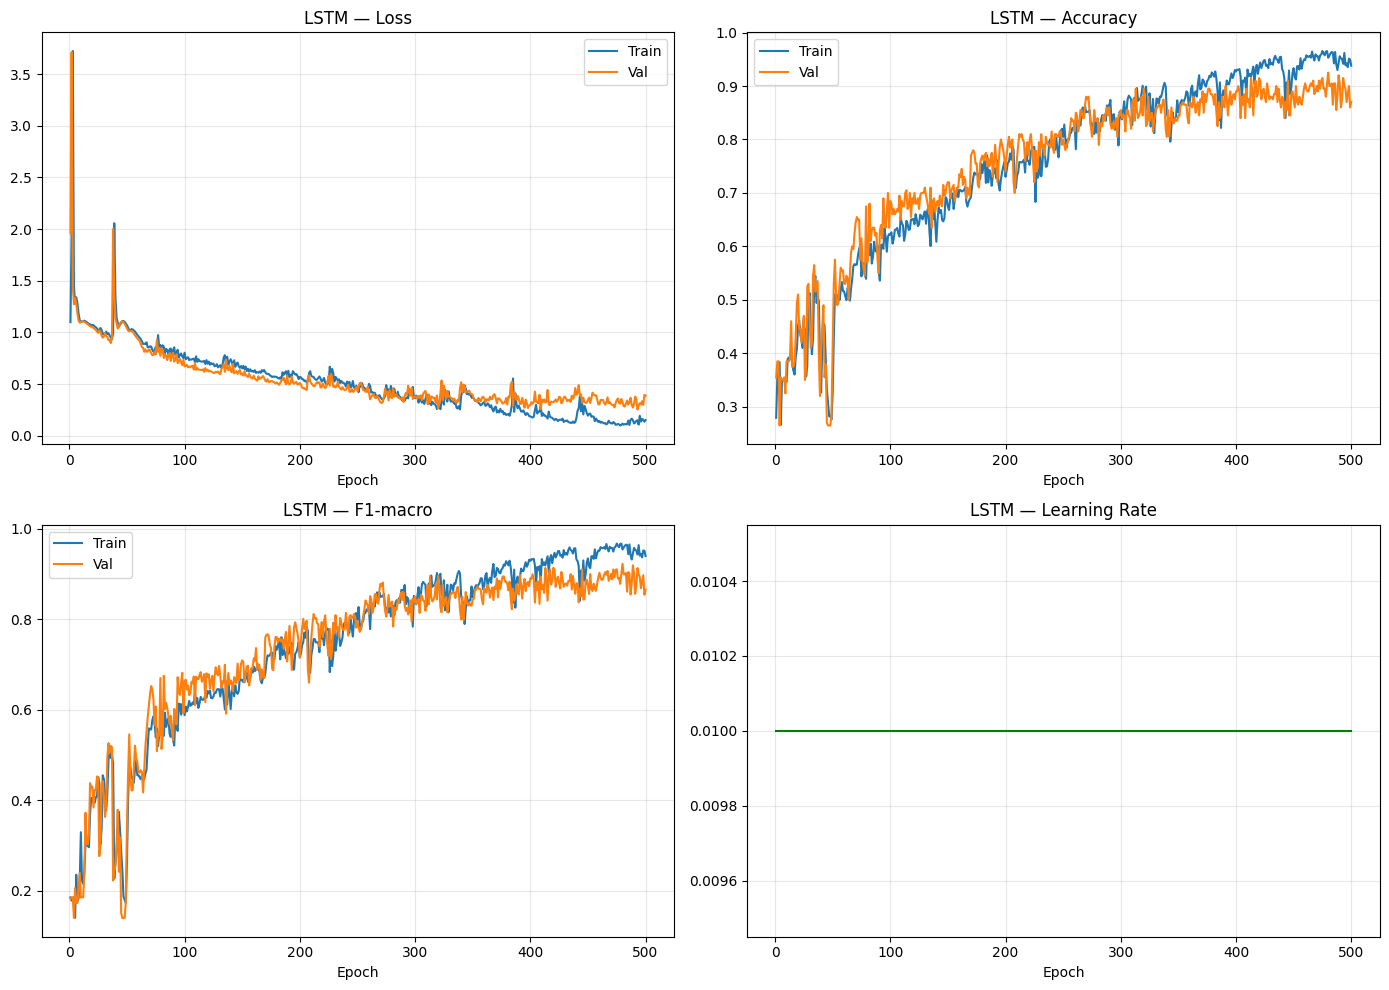

Figure sauvegardée → /kaggle/working/fall_lstm_gru/LSTM_.png

LSTM — Évaluation TEST SET (checkpoint epoch 480)
Test accuracy : 0.8554   Test F1-macro : 0.8556

              precision    recall  f1-score   support

        fall     0.8916    0.8409    0.8655        88
      nfall1     0.8828    0.8898    0.8863       127
      nfall2     0.8017    0.8291    0.8151       117

    accuracy                         0.8554       332
   macro avg     0.8587    0.8532    0.8556       332
weighted avg     0.8565    0.8554    0.8557       332



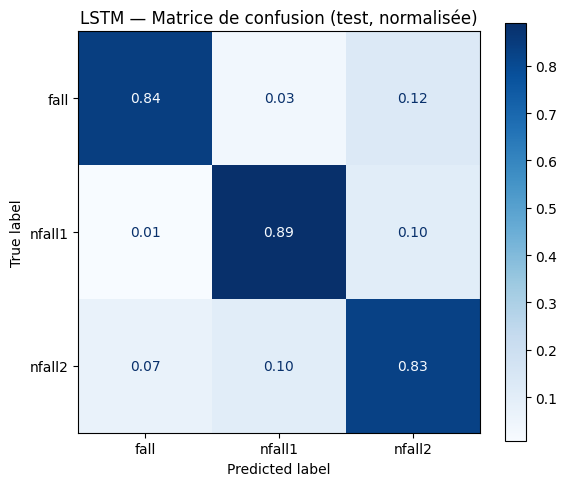

✅ LSTM enregistré


In [9]:
# ============================================================
# CELLULE 9 — LSTM (hidden=512, lr=0.01 — meilleurs hyperparamètres du papier, RP-Normalization)
# ============================================================
model_lstm = SequenceFallNet("lstm", hidden_size=LSTM_HIDDEN).to(DEVICE)
n_params_lstm = sum(p.numel() for p in model_lstm.parameters())
print(f"LSTM — paramètres : {n_params_lstm:,}")

history_lstm, ckpt_best_lstm, best_val_f1_lstm = train_full_seq(model_lstm, "LSTM", epochs=EPOCHS_SEQ, lr=LR_LSTM)
plot_history(history_lstm, title_prefix="LSTM — ")
test_metrics_lstm = evaluate_on_test_seq(model_lstm, ckpt_best_lstm, name="LSTM")

all_results["LSTM"] = {
    "history": history_lstm, "ckpt_best": ckpt_best_lstm,
    "best_val_f1": best_val_f1_lstm, "n_params": n_params_lstm, **test_metrics_lstm,
}
del model_lstm
gc.collect(); torch.cuda.empty_cache()
print("✅ LSTM enregistré")


# GRU

GRU — paramètres : 834,051

Entraînement : GRU — 500 epochs (full-batch, 1127 séquences)
[GRU] Epoch   1/500 | train_f1=0.2073 | val_loss=3.1409 val_acc=0.3500 val_f1=0.1728 ⭐ best
[GRU] Epoch   2/500 | train_f1=0.1730 | val_loss=1.5245 val_acc=0.3850 val_f1=0.1894 ⭐ best
[GRU] Epoch   4/500 | train_f1=0.1402 | val_loss=1.1669 val_acc=0.3500 val_f1=0.2902 ⭐ best
[GRU] Epoch   6/500 | train_f1=0.2830 | val_loss=1.0824 val_acc=0.5300 val_f1=0.4489 ⭐ best
[GRU] Epoch  25/500 | train_f1=0.2504 | val_loss=1.1507 val_acc=0.3250 val_f1=0.2911
[GRU] Epoch  50/500 | train_f1=0.3306 | val_loss=1.0032 val_acc=0.4850 val_f1=0.4887 ⭐ best
[GRU] Epoch  60/500 | train_f1=0.4172 | val_loss=0.8899 val_acc=0.5650 val_f1=0.5169 ⭐ best
[GRU] Epoch  75/500 | train_f1=0.4544 | val_loss=0.9220 val_acc=0.5200 val_f1=0.4912
[GRU] Epoch  76/500 | train_f1=0.4731 | val_loss=0.8863 val_acc=0.5650 val_f1=0.5210 ⭐ best
[GRU] Epoch  79/500 | train_f1=0.5126 | val_loss=0.8908 val_acc=0.5650 val_f1=0.5699 ⭐ best
[GRU]

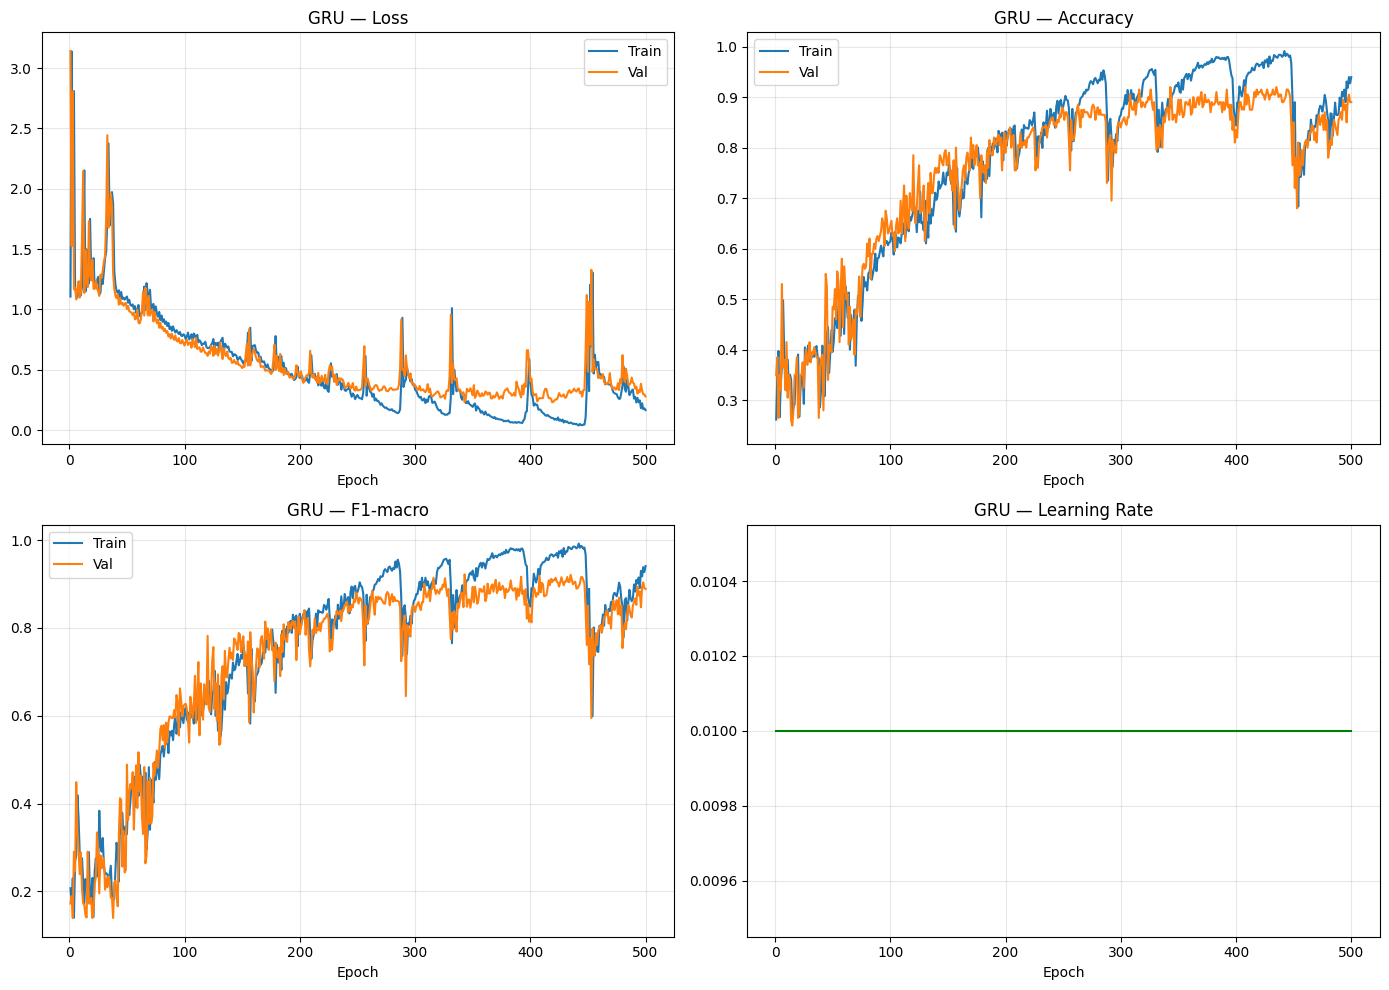

Figure sauvegardée → /kaggle/working/fall_lstm_gru/GRU_.png

GRU — Évaluation TEST SET (checkpoint epoch 343)
Test accuracy : 0.8554   Test F1-macro : 0.8580

              precision    recall  f1-score   support

        fall     0.8542    0.9318    0.8913        88
      nfall1     0.9217    0.8346    0.8760       127
      nfall2     0.7934    0.8205    0.8067       117

    accuracy                         0.8554       332
   macro avg     0.8564    0.8623    0.8580       332
weighted avg     0.8586    0.8554    0.8557       332



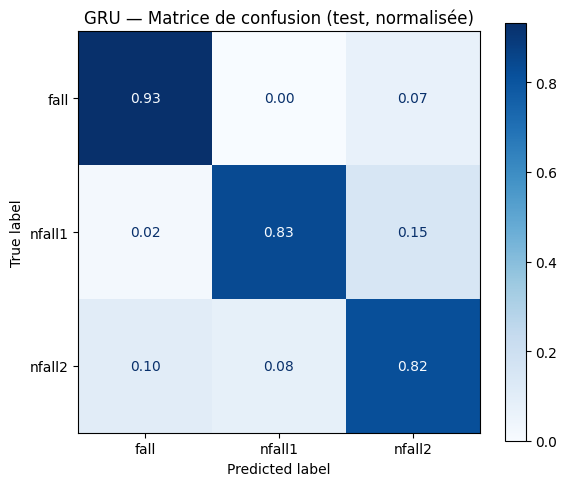

✅ GRU enregistré


In [10]:
# ============================================================
# CELLULE 10 — GRU (hidden=512, lr=0.01 — meilleurs hyperparamètres du papier, RP-Normalization)
# ============================================================
model_gru = SequenceFallNet("gru", hidden_size=GRU_HIDDEN).to(DEVICE)
n_params_gru = sum(p.numel() for p in model_gru.parameters())
print(f"GRU — paramètres : {n_params_gru:,}")

history_gru, ckpt_best_gru, best_val_f1_gru = train_full_seq(model_gru, "GRU", epochs=EPOCHS_SEQ, lr=LR_GRU)
plot_history(history_gru, title_prefix="GRU — ")
test_metrics_gru = evaluate_on_test_seq(model_gru, ckpt_best_gru, name="GRU")

all_results["GRU"] = {
    "history": history_gru, "ckpt_best": ckpt_best_gru,
    "best_val_f1": best_val_f1_gru, "n_params": n_params_gru, **test_metrics_gru,
}
del model_gru
gc.collect(); torch.cuda.empty_cache()
print("✅ GRU enregistré")


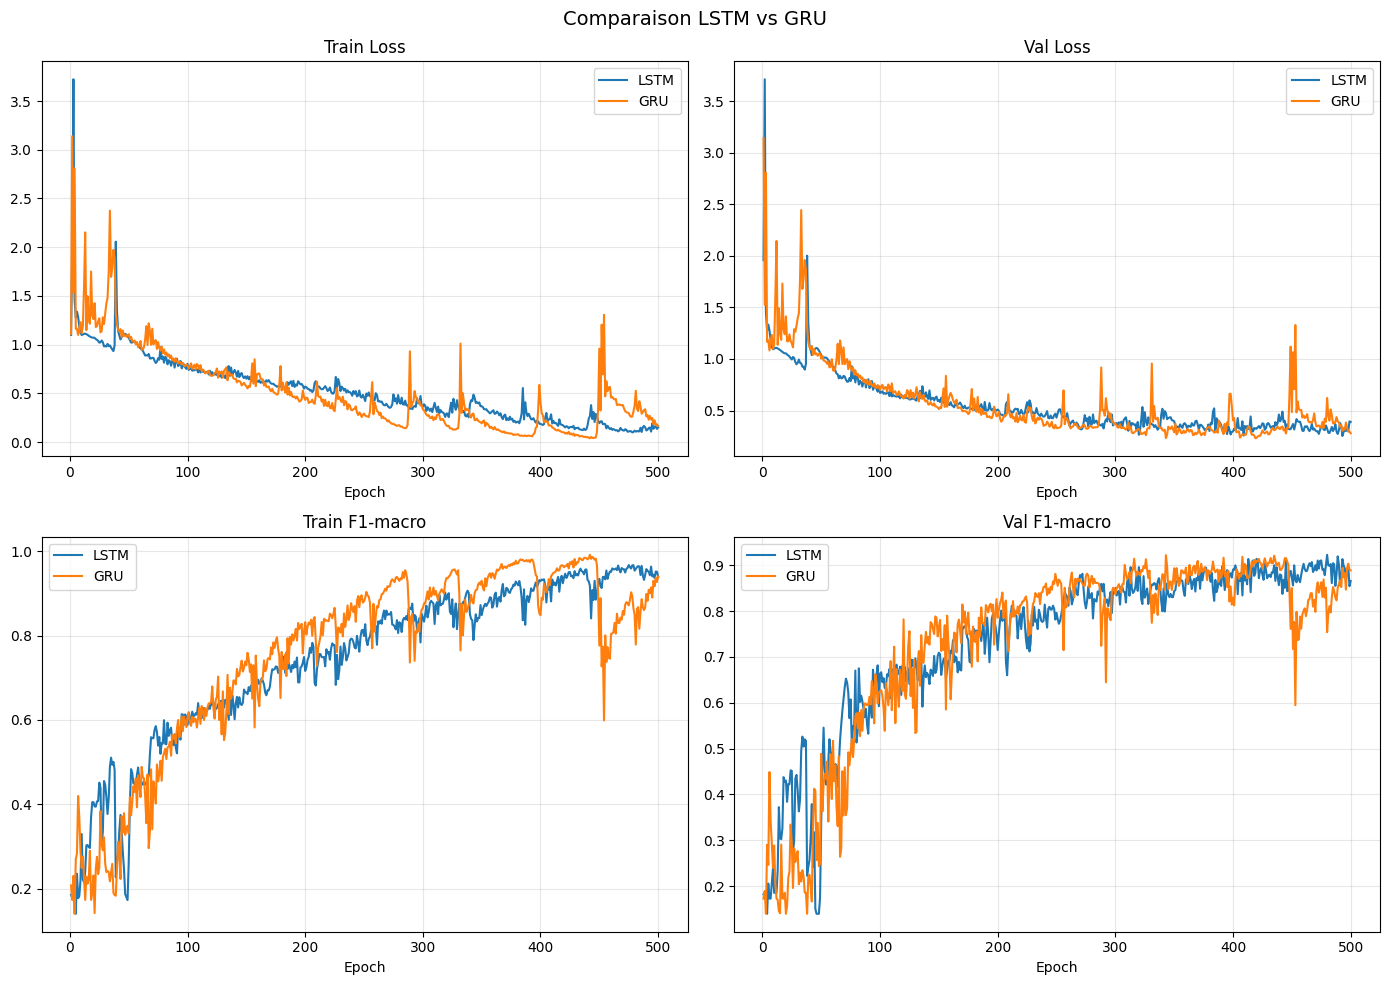

Modèle    Params Best val_f1 Test accuracy Test F1-macro Gap train-val F1 (fin)
  LSTM 1,111,555      0.9228        0.8554        0.8556                 0.0744
   GRU   834,051      0.9219        0.8554        0.8580                 0.0518


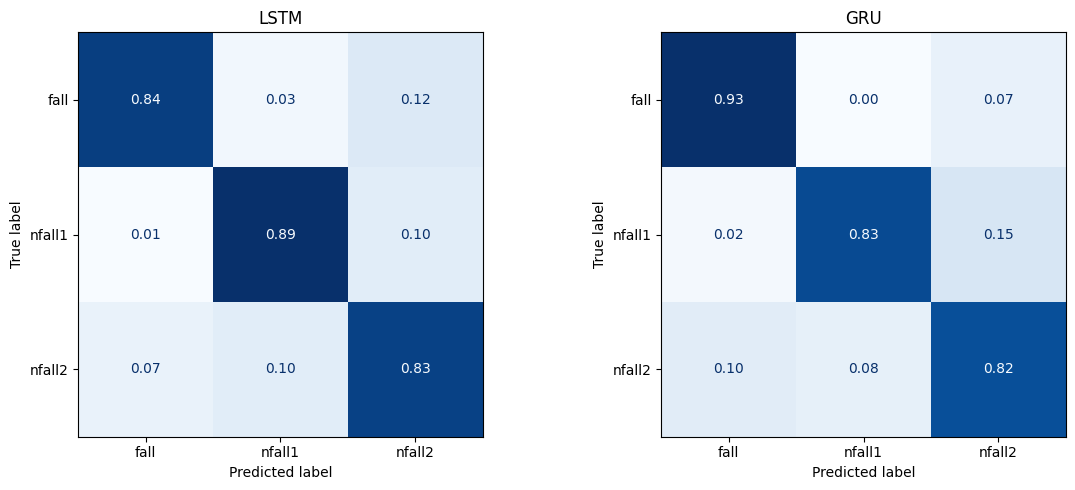


✅ Comparaison LSTM/GRU terminée — fichiers sauvegardés dans /kaggle/working/fall_lstm_gru
   Séquences totales : 1659  (stride=20)  |  Train: 1127  Val: 200  Test: 332


In [12]:
# ============================================================
# CELLULE 11 — COMPARAISON FINALE : LSTM vs GRU
# ============================================================
seq_models = ["LSTM", "GRU"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for name in seq_models:
    h = all_results[name]["history"]
    epochs_range = range(1, len(h["train_loss"]) + 1)
    axes[0,0].plot(epochs_range, h["train_loss"], label=name)
    axes[0,1].plot(epochs_range, h["val_loss"], label=name)
    axes[1,0].plot(epochs_range, h["train_f1"], label=name)
    axes[1,1].plot(epochs_range, h["val_f1"], label=name)
axes[0,0].set_title("Train Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,1].set_title("Val Loss");   axes[0,1].set_xlabel("Epoch"); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[1,0].set_title("Train F1-macro"); axes[1,0].set_xlabel("Epoch"); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)
axes[1,1].set_title("Val F1-macro");   axes[1,1].set_xlabel("Epoch"); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)
plt.suptitle("Comparaison LSTM vs GRU", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "comparison_lstm_gru_curves.png"), dpi=120)
plt.show()

summary_rows = []
for name in seq_models:
    r = all_results[name]
    h = r["history"]
    gap = h["train_f1"][-1] - h["val_f1"][-1]
    summary_rows.append({
        "Modèle": name,
        "Params": f"{r['n_params']:,}",
        "Best val_f1": f"{r['best_val_f1']:.4f}",
        "Test accuracy": f"{r['test_acc']:.4f}",
        "Test F1-macro": f"{r['test_f1_macro']:.4f}",
        "Gap train-val F1 (fin)": f"{gap:.4f}",
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(OUT_DIR, "comparison_lstm_gru_summary.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, seq_models):
    r = all_results[name]
    ConfusionMatrixDisplay.from_predictions(
        r["y_true"], r["y_pred"], display_labels=list(CLASSES.keys()),
        ax=ax, cmap="Blues", normalize="true", values_format=".2f", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "comparison_lstm_gru_confmats.png"), dpi=120)
plt.show()

print(f"\n✅ Comparaison LSTM/GRU terminée — fichiers sauvegardés dans {OUT_DIR}")
print(f"   Séquences totales : {len(y_seq)}  (stride={STRIDE})  |  Train: {X_train_seq.shape[0]}  "
      f"Val: {X_val_seq.shape[0]}  Test: {X_test_seq.shape[0]}")


Test set : 332 séquences — jamais utilisées pour l'entraînement ni pour la sélection du meilleur epoch (val uniquement).


LSTM (re-vérif.) — Évaluation TEST SET (checkpoint epoch 480)
Test accuracy : 0.8554   Test F1-macro : 0.8556

              precision    recall  f1-score   support

        fall     0.8916    0.8409    0.8655        88
      nfall1     0.8828    0.8898    0.8863       127
      nfall2     0.8017    0.8291    0.8151       117

    accuracy                         0.8554       332
   macro avg     0.8587    0.8532    0.8556       332
weighted avg     0.8565    0.8554    0.8557       332



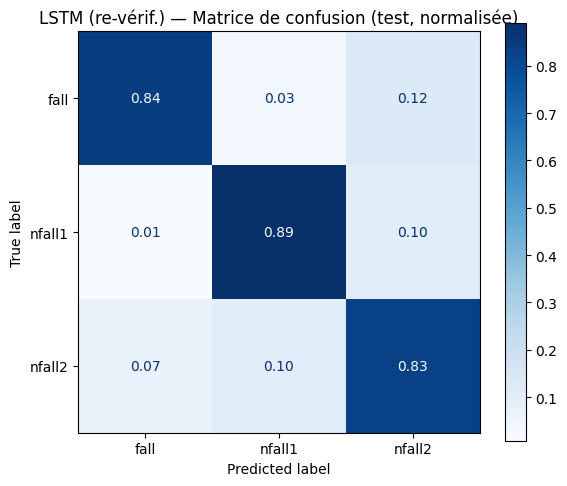


GRU (re-vérif.) — Évaluation TEST SET (checkpoint epoch 343)
Test accuracy : 0.8554   Test F1-macro : 0.8580

              precision    recall  f1-score   support

        fall     0.8542    0.9318    0.8913        88
      nfall1     0.9217    0.8346    0.8760       127
      nfall2     0.7934    0.8205    0.8067       117

    accuracy                         0.8554       332
   macro avg     0.8564    0.8623    0.8580       332
weighted avg     0.8586    0.8554    0.8557       332



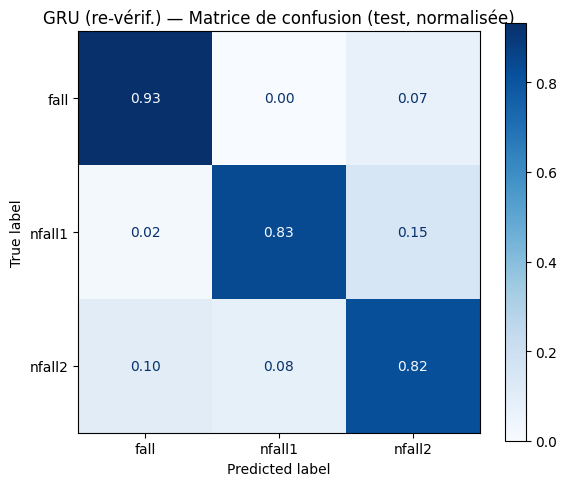


✅ Ré-évaluation indépendante terminée — mêmes chiffres attendus que lors de l'entraînement initial :
  LSTM: test_acc=0.8554  test_f1_macro=0.8556
  GRU: test_acc=0.8554  test_f1_macro=0.8580


In [13]:
# ============================================================
# CELLULE 12 — VÉRIFICATION INDÉPENDANTE SUR LE TEST SET
# (jamais vu pendant l'entraînement, ni pour le choix du checkpoint)
# ============================================================
print(f"Test set : {X_test_seq.shape[0]} séquences — "
      f"jamais utilisées pour l'entraînement ni pour la sélection du meilleur epoch (val uniquement).\n")

final_test_results = {}
for name, hidden in [("LSTM", LSTM_HIDDEN), ("GRU", GRU_HIDDEN)]:
    ckpt_path = os.path.join(OUT_DIR, f"best_{name}.pt")
    cell_type = name.lower()
    model = SequenceFallNet(cell_type, hidden_size=hidden).to(DEVICE)
    result = evaluate_on_test_seq(model, ckpt_path, name=f"{name} (re-vérif.)")
    final_test_results[name] = result
    del model
    gc.collect(); torch.cuda.empty_cache()

print("\n✅ Ré-évaluation indépendante terminée — mêmes chiffres attendus que lors de l'entraînement initial :")
for name, r in final_test_results.items():
    print(f"  {name}: test_acc={r['test_acc']:.4f}  test_f1_macro={r['test_f1_macro']:.4f}")

In [16]:
# ============================================================
# CELLULE 12bis — Test sur UN seul exemple du test set
# ============================================================
idx = 0  # change cet index pour tester un autre exemple

ckpt_lstm = load_ckpt(os.path.join(OUT_DIR, "best_LSTM.pt"))
model_lstm_eval = SequenceFallNet("lstm", hidden_size=LSTM_HIDDEN).to(DEVICE)
model_lstm_eval.load_state_dict(ckpt_lstm["model_state"])
model_lstm_eval.eval()

sample_X = X_test_seq[idx:idx+1]   # une seule séquence
sample_y = y_test_seq[idx].item()

with torch.no_grad():
    pred = model_lstm_eval(sample_X).argmax(dim=1).item()

print(f"Sample X (index {idx})")
print(f"  Classe réelle      : {IDX2CLASS[sample_y]}")
print(f"  Prédiction LSTM     : {IDX2CLASS[pred]}")
print(f"  Correct ?           : {'✅ oui' if pred == sample_y else '❌ non'}")

del model_lstm_eval
gc.collect(); torch.cuda.empty_cache()

Sample X (index 0)
  Classe réelle      : fall
  Prédiction LSTM     : fall
  Correct ?           : ✅ oui


## Tableau comparatif — tous les modèles testés (OpenPose)

| Modèle | Tâche | Params | Best val F1 | Test accuracy | Test F1-macro | Gap train-val F1 (fin) |
|---|---|---|---|---|---|---|
| MobileNetV2 | Classification image (heatmap OpenPose) | 2,608,677 | 0.9802 | 0.9788 | 0.9787 | ≈ 0 (voir éval "propre") |
| MobileNetV3 | Classification image (heatmap OpenPose) | 4,579,061 | 0.9766 | 0.9788 | 0.9784 | ≈ 0 (voir éval "propre") |
| MobileNetV4 | Classification image (heatmap OpenPose) | 2,877,829 | 0.9826 | 0.9818 | 0.9817 | ≈ 0 (voir éval "propre") |
| LSTM | Classification séquence (keypoints, fenêtre de 100 frames) | 1,111,555 | 0.9228 | 0.8554 | 0.8556 | 0.0744 |
| GRU | Classification séquence (keypoints, fenêtre de 100 frames) | 834,051 | 0.9219 | 0.8554 | 0.8580 | 0.0518 |

**Notes :**
- Les modèles MobileNetV2/V3/V4 sont entraînés et évalués sur des **frames individuelles** (6030 images de test), tandis que LSTM et GRU sont évalués sur des **séquences temporelles de 100 frames** (332 séquences de test, stride = 20).
- Le "Gap train-val F1" des MobileNet paraît artificiellement élevé sur les courbes brutes d'entraînement à cause du MixUp et du Dropout actifs pendant l'entraînement. Une évaluation "propre" (sans ces deux techniques) montre train ≈ val ≈ test ≈ 0.98 pour les trois modèles CNN, confirmant l'absence d'overfitting réel.
- Pour LSTM et GRU, le gap de 0.05 à 0.07 est réel mais modéré, cohérent avec un dataset de séquences nettement plus restreint (1127 séquences d'entraînement contre plusieurs dizaines de milliers de frames pour les CNN).